In [716]:
import numpy as np
from numpy.typing import ArrayLike
import pandas as pd

np.set_printoptions(precision=3)
eps = 1e-12
np.random.seed(42)

def rosembrock_2d(theta:ArrayLike, a:float=1., b:float=100.) -> float:
    return (a - theta[0]) ** 2 + b * (theta[1] - theta[0] ** 2)**2

def rosembrock_2d_prime(theta:ArrayLike, a:float=1, b:float=100.) -> ArrayLike:
    ftheta = 2 * (theta[0] - a) - 4 * b * theta[0] * (theta[1]-theta[0]**2)
    fy = 2 * b * (theta[1]-theta[0] ** 2)
    return np.array([ftheta, fy])

fun = rosembrock_2d
fun_grad = rosembrock_2d_prime

def print_stats_sometimes(step, steps, theta, fun):
    if step % (steps // 10) == 0:
        print(f"{step=}, {theta=}, {fun(theta):3.3}")
        
steps = 5000
history = {}

In [717]:
# Gradient Descend (2D)
lr = 1e-3
theta = np.random.random(size=(2, ))
step = 0
history["sgd"] = []

while step < steps:
    print_stats_sometimes(step, steps, theta, fun)
    grad_theta = fun_grad(theta) # gradients, shape (N, ) 
    theta -= lr * grad_theta
    step += 1
    history["sgd"].append(fun(theta))

print(f"\n{step=}, {theta}, {fun(theta)}")


step=0, theta=array([0.375, 0.951]), 66.1
step=500, theta=array([0.815, 0.663]), 0.0343
step=1000, theta=array([0.858, 0.735]), 0.0203
step=1500, theta=array([0.889, 0.789]), 0.0124
step=2000, theta=array([0.912, 0.832]), 0.00775
step=2500, theta=array([0.93 , 0.864]), 0.00492
step=3000, theta=array([0.944, 0.891]), 0.00316
step=3500, theta=array([0.955, 0.911]), 0.00205
step=4000, theta=array([0.963, 0.928]), 0.00134
step=4500, theta=array([0.97 , 0.942]), 0.000877

step=5000, [0.976 0.952], 0.0005780029717472487


<Axes: xlabel='steps', ylabel='loss'>

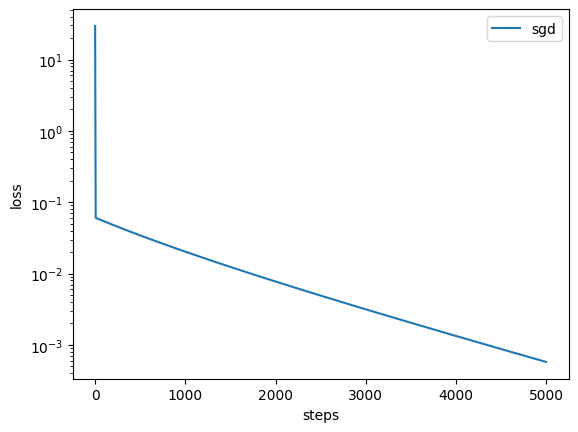

In [718]:
pd.DataFrame(history).plot(logy=True, xlabel="steps", ylabel="loss")

In [719]:
# adding momentum: remember the update dtheta at the last step, 
# and find the new state as a linear combination between the 
# last state and the last update
lr = 1e-3
theta, dtheta = np.random.random(size=(2, )), np.zeros_like(theta)
alpha = 0.5
step = 0
history["sgd_momentum"] = []

while step < steps:
    print_stats_sometimes(step, steps, theta, fun)
    grad_theta = fun_grad(theta)  # gradients, shape (N, ) 
    dtheta = alpha * dtheta - lr * grad_theta # <- optimizer params, shape (N, ) 
    theta += dtheta 
    step += 1
    history["sgd_momentum"].append(fun(theta))

print(f"\n{step=}, {theta=}, {fun(theta)}")

step=0, theta=array([0.732, 0.599]), 0.467
step=500, theta=array([0.861, 0.741]), 0.0192
step=1000, theta=array([0.914, 0.835]), 0.00737
step=1500, theta=array([0.945, 0.893]), 0.00301
step=2000, theta=array([0.964, 0.93 ]), 0.00127
step=2500, theta=array([0.977, 0.954]), 0.000551
step=3000, theta=array([0.984, 0.969]), 0.000242
step=3500, theta=array([0.99 , 0.979]), 0.000107
step=4000, theta=array([0.993, 0.986]), 4.75e-05
step=4500, theta=array([0.995, 0.991]), 2.12e-05

step=5000, theta=array([0.997, 0.994]), 9.47921399028218e-06


<Axes: xlabel='steps', ylabel='loss'>

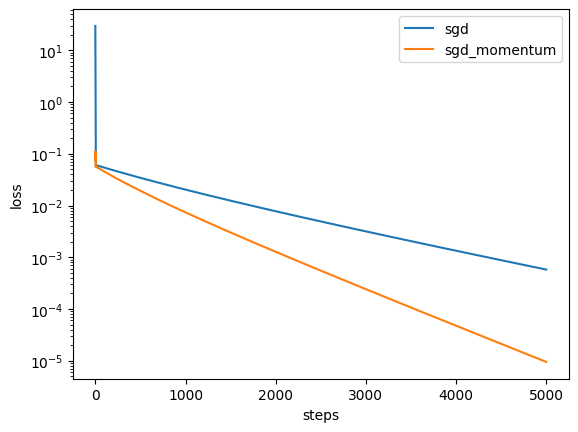

In [720]:
pd.DataFrame(history).plot(logy=True, xlabel="steps", ylabel="loss")

In [721]:
# ## Adagrad: each parameter has its own learning rate
# lr = 1
# theta, G = np.random.random(size=(2, )), np.zeros_like(theta)
# step = 0
# history["adagrad"] = []

# while step < steps:
#     print_stats_sometimes(step, steps, theta, fun)
    
#     grad_theta = fun_grad(theta)
#     G += grad_theta * grad_theta # <- (N, ) shape vector 

#     theta -= lr * grad_theta / (np.sqrt(G) + eps)
#     step += 1
#     history["adagrad"].append(fun(theta))

# print(f"\n{step=}, {theta=}, {fun(theta)}")

<Axes: xlabel='steps', ylabel='loss'>

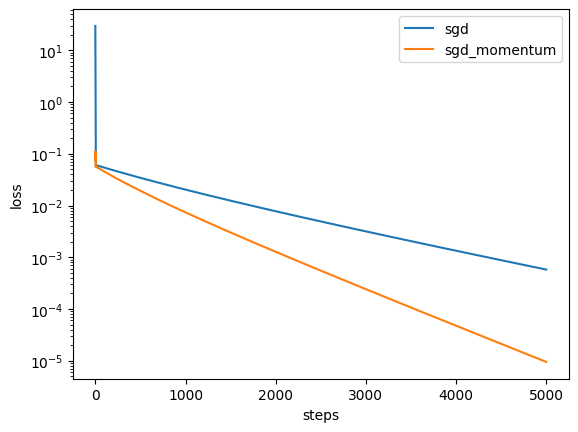

In [722]:
pd.DataFrame(history).plot(logy=True, xlabel="steps", ylabel="loss")

In [723]:
# RMSProp: divide the learning rate by a factor that is the running 
# average of the magnitudes of recent gradients for that weight
lr = 1e-3
theta, v = np.random.random(size=(2, )), np.zeros_like(theta)
gamma: float = 0.99
step = 0
history["rmsprop"] = []

while step < steps:
    print_stats_sometimes(step, steps, theta, fun)
    
    grad_theta = fun_grad(theta) # gradients, shape (N, ) 
    v = gamma * v + (1 - gamma) * grad_theta ** 2 # <- optimizer params, shape (N, ) 

    theta -= lr * grad_theta / (np.sqrt(v) + eps)
    step += 1
    history["rmsprop"].append(fun(theta))

print(f"\n{step=}, {theta}, {fun(theta)}")

step=0, theta=array([0.156, 0.156]), 2.45
step=500, theta=array([0.492, 0.239]), 0.259
step=1000, theta=array([0.774, 0.599]), 0.051
step=1500, theta=array([0.895, 0.802]), 0.0111
step=2000, theta=array([0.945, 0.895]), 0.00317
step=2500, theta=array([0.97 , 0.942]), 0.0011
step=3000, theta=array([0.983, 0.967]), 0.000499
step=3500, theta=array([0.99 , 0.982]), 0.000314
step=4000, theta=array([0.994, 0.99 ]), 0.000254
step=4500, theta=array([0.996, 0.994]), 0.000235

step=5000, [0.998 0.997], 0.00022856833096362015


<Axes: xlabel='steps', ylabel='loss'>

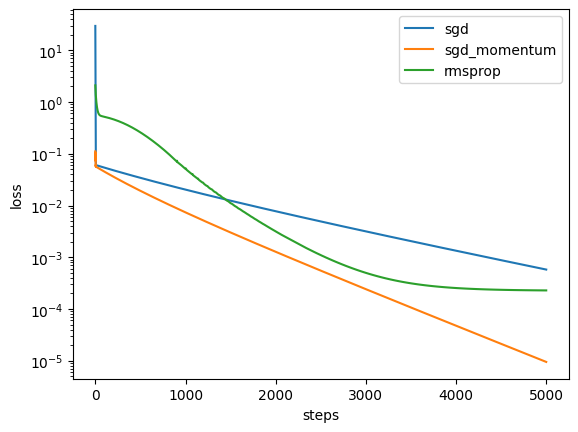

In [724]:
pd.DataFrame(history).plot(logy=True, xlabel="steps", ylabel="loss")

In [725]:
def print_stats_sometimes(step, steps, theta, fun):
    if step % (steps // 5) == 0:
        print(f"{step=}, {theta=}, {fun(theta):3.3}")

In [726]:
# Adam: combine RMSprop with momentum. 
lr = 2e-4
theta = np.random.random(size=(2, ))
v, m = np.zeros_like(theta), np.zeros_like(theta)
beta_v, beta_m = 0.9, 0.9
step = 0
history["adam"] = []

while step < steps:
    print_stats_sometimes(step, steps, theta, fun)
    
    grad_theta = fun_grad(theta) # gradients, shape (N, ) 
    m = beta_m * m + (1 - beta_m) * grad_theta  # <- optimizer params, shape (N, ) 
    v = beta_v * v + (1 - beta_v) * grad_theta ** 2 # <- optimizer params, shape (N, ) 

    v /= (1 - beta_v ** (step+1))
    m /= (1 - beta_m ** (step+1))

    theta -= lr * m / (np.sqrt(v) + eps)
    step += 1
    history["adam"].append(fun(theta))

print(f"\n{step=}, {theta=}, {fun(theta)}")

step=0, theta=array([0.058, 0.866]), 75.3
step=1000, theta=array([0.684, 0.466]), 0.1
step=2000, theta=array([0.817, 0.666]), 0.0338
step=3000, theta=array([0.931, 0.866]), 0.00484
step=4000, theta=array([1., 1.]), 5.86e-09

step=5000, theta=array([1., 1.]), 4.82987351556147e-09


<Axes: xlabel='steps', ylabel='loss'>

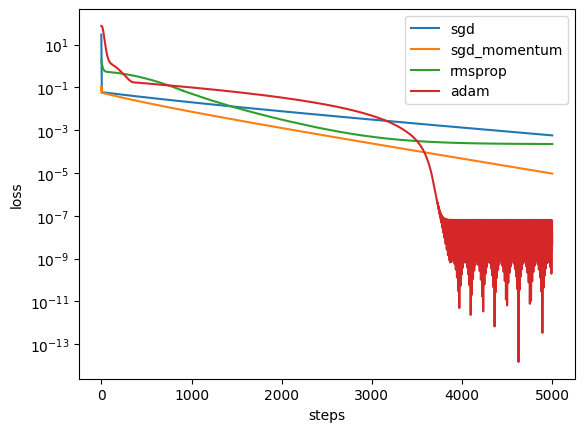

In [727]:
pd.DataFrame(history).plot(logy=True, xlabel="steps", ylabel="loss")

In [728]:
def rosembrock_2d_hessian(theta:ArrayLike, a:float=1, b:float=100.) -> ArrayLike:
    x, y = theta
    hess_11 = 2 - 4 * b * (y - 3 * x ** 2)
    hess_12 = - 4 * b * x
    hess_21 = hess_12
    hess_22 = 2 * b
    return np.array([[hess_11, hess_12], [hess_21, hess_22]])

# Newton: full 2nd order method
lr = 2e-4
theta = np.random.random(size=(2, ))
step = 0
steps = 10
history["full_newton"] = []

while step < steps:
    print_stats_sometimes(step, steps, theta, fun)
    
    grad_theta = fun_grad(theta) # gradients, shape (N, ) 
    hess_theta = rosembrock_2d_hessian(theta) # <- hessian, shape (N, N) 

    theta -=  np.linalg.solve(hess_theta, grad_theta)
    step += 1
    history["full_newton"].append(fun(theta))

print(f"\n{step=}, {theta=}, {fun(theta)}")
history["full_newton"] += [np.nan] * (len(history["adam"])-len(history["full_newton"]))

step=0, theta=array([0.601, 0.708]), 12.2
step=2, theta=array([0.997, 0.833]), 2.61
step=4, theta=array([1., 1.]), 4.98e-09
step=6, theta=array([1., 1.]), 0.0
step=8, theta=array([1., 1.]), 0.0

step=10, theta=array([1., 1.]), 0.0


<Axes: xlabel='steps', ylabel='loss'>

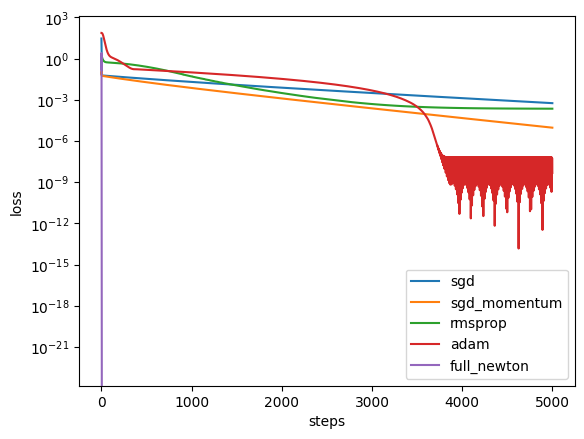

In [729]:
pd.DataFrame(history, ).plot(logy=True, xlabel="steps", ylabel="loss")

<Axes: xlabel='steps', ylabel='loss'>

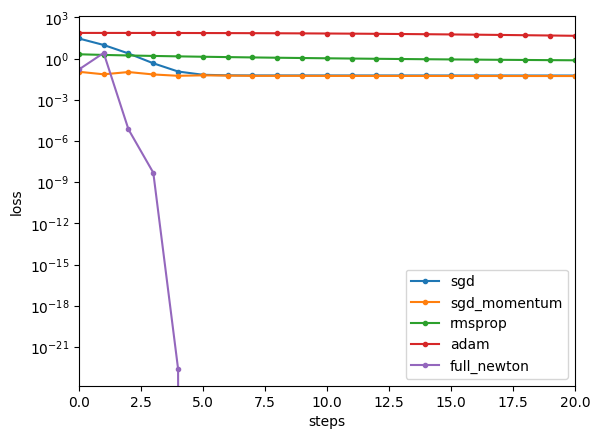

In [730]:
pd.DataFrame(history, ).plot(style='.-', logy=True, xlabel="steps", ylabel="loss", xlim=[0, 20])

<Axes: xlabel='steps', ylabel='loss'>

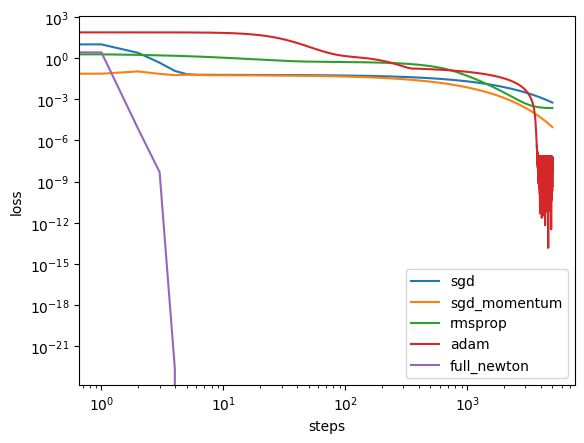

In [731]:
pd.DataFrame(history, ).plot(logy=True, xlabel="steps", ylabel="loss", logx=True)
